In [318]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds, get_normalized_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [319]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [320]:
# Encoder Class
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(2 * hidden_dim, latent_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        return x

# Decoder Class
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.lstm1 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_dim, output_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        return x

In [321]:
# Autoencoder Class
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [322]:
# Trainer Class
class Trainer:
    def __init__(self, model, train_dataset, test_dataset, variable, n_classes, index_to_class, batch_size=64, lr=0.001, epochs=100):
        self.model = model
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.variable = variable
        self.n_classes = n_classes
        self.index_to_class = index_to_class
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.test_dataloader = DataLoader(test_dataset, len(test_dataset), shuffle=False)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        self.train_losses = []
        
    def train(self):
        self.model.train()
        for epoch in tqdm(range(self.epochs)):
            for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                data = data[:, :, self.variable].unsqueeze(2).float()
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, data)
                loss.backward()
                self.optimizer.step()
            self.train_losses.append(loss.item())
            
    def plot_losses(self):
        plt.plot(self.train_losses)
        plt.title('Train Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.show()

    def plot_epilepsy_reconstructions(self):
        self.model.eval()
        for data_matrix, labels in self.test_dataloader:
            inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
            with torch.no_grad():
                output = self.model(inp)
                print("Blue = original, Red = reconstructed")
                plt.figure()
                index = random.randint(0, 33)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Epilepsy")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(34, 70)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(71, 106)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(107, 136)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]


                plt.title("Sawing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.show()


In [323]:
# Load in Epilepsy dataset
class_to_index={"epilepsy":0, "walking":1, "running":2,"sawing":3}
index_to_class={0:"Epilepsy", 1:"Walking", 2:"Running", 3:"Sawing", 4:"Prototype"}
train_ds, test_ds = get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TRAIN.ts", class_to_index), get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TEST.ts", class_to_index)
len(train_ds)

40

In [324]:
model = Autoencoder(
    input_dim=1,
    hidden_dim=256,
    latent_dim=128,
    output_dim=1,
)
trainer = Trainer(
    model=model,
    train_dataset=train_ds,
    test_dataset=test_ds,
    variable=0,
    n_classes=4,
    index_to_class=index_to_class,
    batch_size=32,
    lr=0.001,
    epochs=100
)

In [325]:
trainer.train()

100%|██████████| 200/200 [00:46<00:00,  4.31it/s]


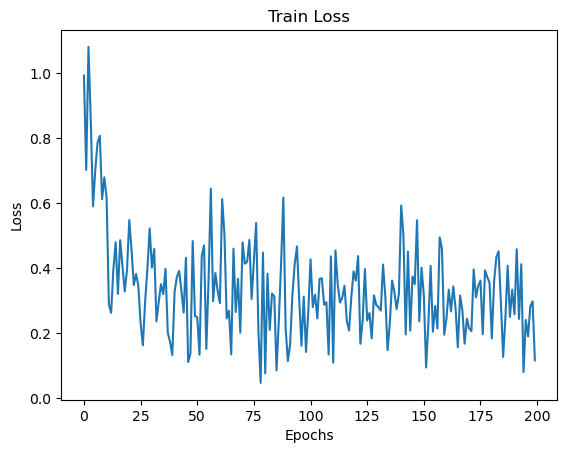

In [326]:
trainer.plot_losses()

Blue = original, Red = reconstructed


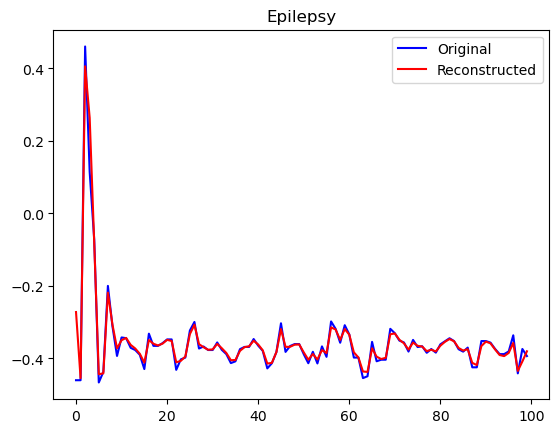

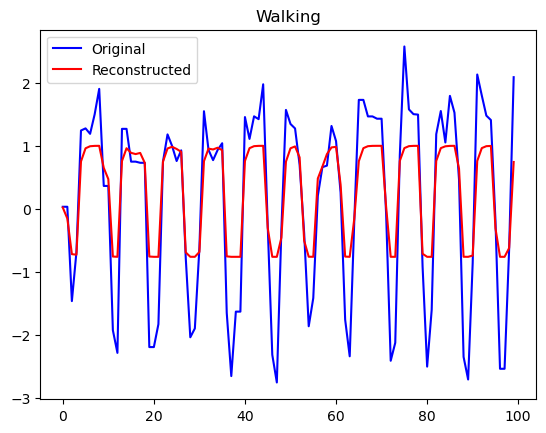

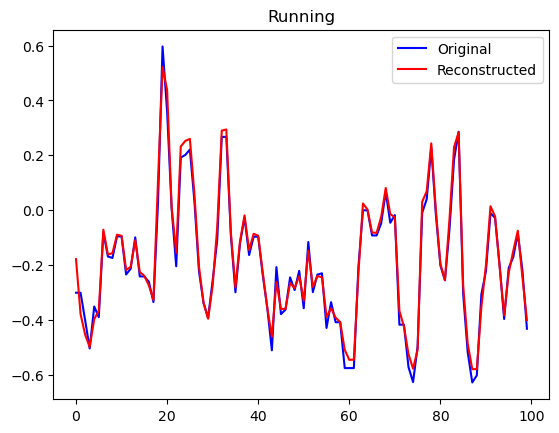

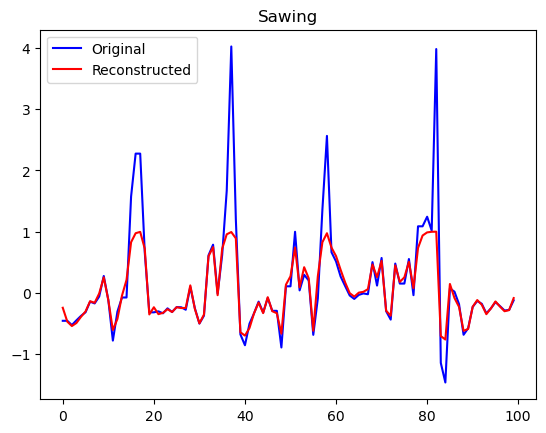

In [331]:
trainer.plot_epilepsy_reconstructions()